<a href="https://colab.research.google.com/github/harmanbajwa2954/Machine-Learning-Notebooks/blob/main/Type_of_Brain_Tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Type of Brain Tumor Detection using MRI images**

## Importing Libraries and Tools

In [ ]:
!git clone https://github.com/harmanbajwa2954/MRI_Brain_Tumor_Detection.git

Cloning into 'MRI_Brain_Tumor_Detection'...
remote: Enumerating objects: 7280, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 7280 (delta 22), reused 35 (delta 3), pack-reused 7211 (from 3)
Receiving objects: 100% (7280/7280), 155.66 MiB | 38.25 MiB/s, done.
Resolving deltas: 100% (25/25), done.
Updating files: 100% (7501/7501), done.
Filtering content: 100% (2/2), 244.47 MiB | 10.58 MiB/s, done.


In [ ]:
!pip install tensorflow

import os #for directory and file operations
import numpy as np
import random
from PIL import Image, ImageEnhance # Pillow library used to work with images
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

#keras
from keras.models import Sequential  #for building the model
from keras.layers import Input, Dense, Flatten, Dropout  # for model layers
from keras.preprocessing.image import load_img
from keras.optimizers import Adam    #for optimization
from keras.applications import VGG16 # for using VGG16 model
from keras.callbacks import ReduceLROnPlateau

from sklearn.utils import shuffle # for shuffling the data

In [ ]:
!python --version

Python 3.12.13


## Load Datasets

In [ ]:
# Directories for training and testing data
train_dir = '/content/MRI_Brain_Tumor_Detection/Type_of_Brain_Tumor/Training/'
test_dir = '/content/MRI_Brain_Tumor_Detection/Type_of_Brain_Tumor/Testing/'

#laod and shuffle the train data
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

#load and shuffle the test data
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(test_dir, label, image))
    test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

## Data Visualization

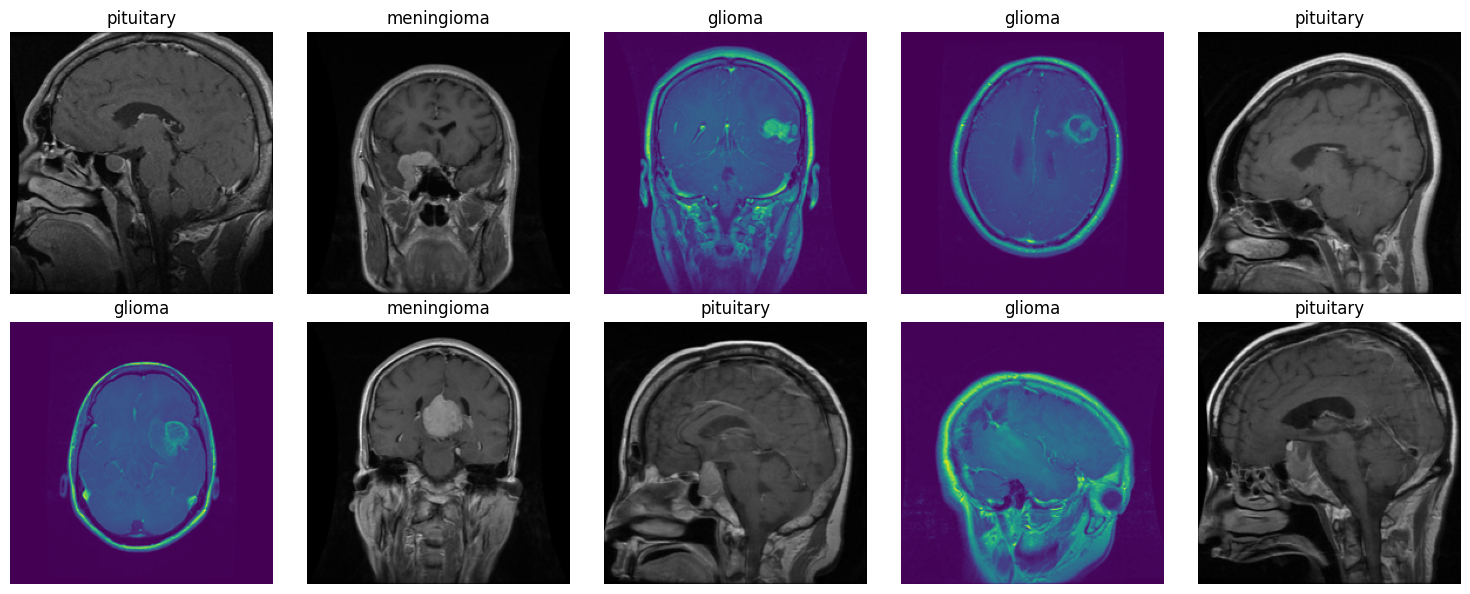

In [ ]:
#selecting random incies for 10 images
random_indices = random.sample(range(len(train_paths)),10)

#Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((224,224))

  #Display images inside the loop
  axes[i].imshow(img)
  axes[i].set_title(train_labels[idx]) # Add title with label
  axes[i].axis("off")

plt.tight_layout()
plt.show()

## Image Preprocessing (Helper Functions)

In [ ]:
from numpy._core.defchararray import encode
#image augmentation fucntion
def augment_image(image):
  image = Image.fromarray(np.uint8(image))
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Sharpness(image).enhance(random.uniform(0.8, 1.2))
  image = np.array(image)/255.0
  return image

#Load images and apply augmentation
def open_images(path):
  image = []
  for img_path in path:
    img = load_img(img_path, target_size=(224,224))
    img = augment_image(img)
    image.append(img)

  return np.array(image)


#Encoder labels : converts label names to integers
def encode_label(labels_to_encode):
  unique_labels = sorted(os.listdir(train_dir)) # Ensure consistent order
  encoded_labels = [unique_labels.index(label) for label in labels_to_encode]
  return np.array(encoded_labels) # Return as a numpy array

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=15):
  for _ in range(epochs):
    for i in range(0, len(paths), batch_size):
      batch_paths = paths[i:i+batch_size]
      batch_images = open_images(batch_paths)
      batch_labels = labels[i:i+batch_size]
      batch_labels = encode_label(batch_labels)
      yield batch_images, batch_labels

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

## **MODEL**

Here for this project we are going to use **VGG16** for Transfer Learning.

> **VGG16** is a pre-trained convolutional neural network (CNN) for image classification.

In [ ]:
# Model architecture
IMAGE_SIZE = 224  # Image size (adjust based on your requirements)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 20

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps,callbacks=[lr_scheduler])

Epoch 1/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 62s 161ms/step - loss: 0.6463 - sparse_categorical_accuracy: 0.7550 - learning_rate: 5.0000e-04
Epoch 2/20
  1/280 ━━━━━━━━━━━━━━━━━━━━ 41s 150ms/step - loss: 0.5140 - sparse_categorical_accuracy: 0.8500

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: loss,sparse_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)


280/280 ━━━━━━━━━━━━━━━━━━━━ 44s 159ms/step - loss: 0.3068 - sparse_categorical_accuracy: 0.8889 - learning_rate: 5.0000e-04
Epoch 3/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 45s 160ms/step - loss: 0.2338 - sparse_categorical_accuracy: 0.9182 - learning_rate: 5.0000e-04
Epoch 4/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 44s 158ms/step - loss: 0.1937 - sparse_categorical_accuracy: 0.9302 - learning_rate: 5.0000e-04
Epoch 5/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 45s 159ms/step - loss: 0.1766 - sparse_categorical_accuracy: 0.9414 - learning_rate: 5.0000e-04
Epoch 6/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 45s 159ms/step - loss: 0.1471 - sparse_categorical_accuracy: 0.9516 - learning_rate: 5.0000e-04
Epoch 7/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 44s 158ms/step - loss: 0.1415 - sparse_categorical_accuracy: 0.9529 - learning_rate: 5.0000e-04
Epoch 8/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 45s 159ms/step - loss: 0.1033 - sparse_categorical_accuracy: 0.9636 - learning_rate: 5.0000e-04
Epoch 9/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 44s 159ms/step - lo

## Train and Vals

<function matplotlib.pyplot.show(close=None, block=None)>

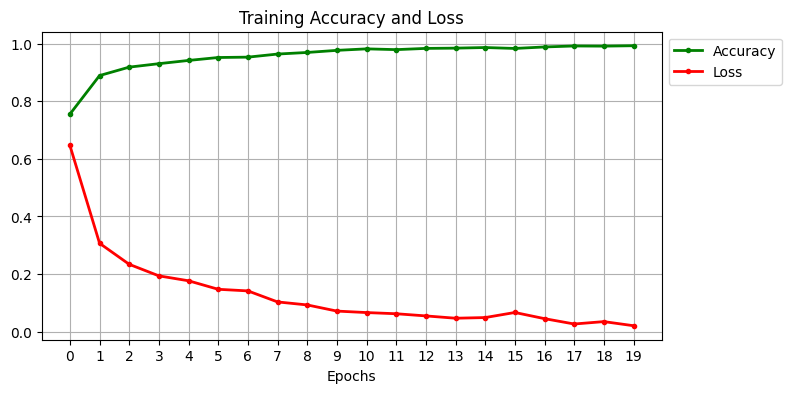

In [ ]:
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'],'.g-',linewidth=2, label='Training Accuracy')
plt.plot(history.history['loss'],'.r-', linewidth=2)
plt.title('Training Accuracy and Loss')
plt.xlabel('Epochs')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy','Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show

### Classification Report

In [ ]:
test_images = open_images(test_paths)
test_label_encoded = encode_label(test_labels)

y_pred = model.predict(test_images)

print('Classification Report:')
print(classification_report(test_label_encoded, np.argmax(y_pred, axis=1)))

### Confusion Matrix

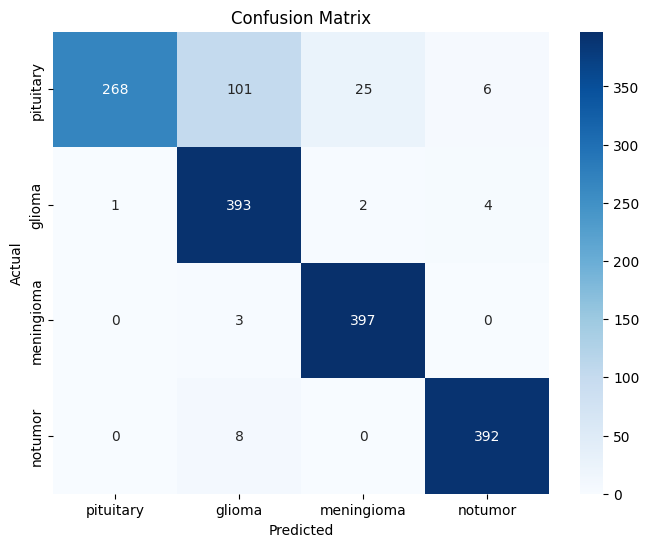

In [ ]:
conf_matrix = confusion_matrix(test_label_encoded, np.argmax(y_pred, axis=1))

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### ROC and AUC curve

In [ ]:
#4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_label_encoded, classes=np.arange(len(os.listdir(train_dir))))
y_pred_bin =y_pred  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i],y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## Saving the model

In [ ]:
# model.save('brain_tumor_model.h5')
model.save('brain_tumortype_model.keras')


### Loading the model

In [ ]:
from keras.models import load_model

bt_model = load_model('brain_tumortype_model.keras')

## MRI Tumor Detection System

In [ ]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np

class_labels = ['meningioma', 'pitutary', 'notumor', 'glioma']

def detect_and_display(image_path, model):
  try:
    #loading image
    img = load_img(image_path, target_size=(128,128))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    #prediction
    predicitons = model.predict(img_array)
    predicted_class_index = np.argmax(predicitons)
    confidence_score = np.max(predicitons, axis=1)[0]

    #determining the class from predicted class
    if class_labels[predicted_class_index] == 'notumor':
      return 'No Tumor Detected'
    else:
      result = f'Tumor Detected: {class_labels[predicted_class_index]}'
    #display
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Prediction: {result}\nConfidence Score: {confidence_score*100:.2f}%')
    plt.show()
  except Exception as e:
    print(f'Error processing the image: {str(e)}')


In [ ]:
img_path = '/content/Te-gl_0015.jpg'
detect_and_display(img_path, bt_model)

Error processing the image: [Errno 2] No such file or directory: '/content/Te-gl_0015.jpg'
